# Sistema de Control de Asistencia por Reconocimiento Facial en Tiempo Real
## Recorrido módulo por módulo del código fuente

**Curso:** Inteligencia Artificial — 7.º ciclo · **Grupo 8**

**Integrantes:**
- León Chacón, Gerardo
- Bohorquez Huaringa, Kevin
- Taco Zavala, Miguel

---

Este notebook recorre **cada módulo** del sistema (`src/`), explicando **qué hace**,
**por qué** y **mostrando sus salidas reales**. La idea es que sirva de guía en la
exposición: cada sección carga el módulo correspondiente, ejecuta un ejemplo y
enseña el resultado (cajas de detección, embeddings, reconocimiento, registro de
asistencia y la interfaz).

> **Cómo ejecutarlo:** correr las celdas **en orden, de arriba hacia abajo**. La
> primera celda de código detecta la raíz del proyecto y prepara los imports.

## Arquitectura general (pipeline)

Cada frame de video atraviesa esta tubería:

```
   Cámara / Video (OpenCV)
        │
        ▼
  YOLOv8 + ByteTrack  ──►  (x1, y1, x2, y2, confianza, track_id)      → detector.py
        │
        ▼
  Recorte del rostro (crop_face)                                      → detector.py
        │
        ▼
  face_recognition / dlib  ──►  embedding de 128 dimensiones          → recognizer.py
        │
        ▼
  Distancia euclidiana vs. centroides de la base (embeddings.pkl)     → recognizer.py
        │                                                               (base: embedding_db.py)
        ▼
  Tracker (periodo de gracia)  ──►  nombre confirmado                 → tracker.py
        │
        ▼
  AsistenciaDB  ──►  registro en CSV diario (sin duplicados)          → asistencia.py
        │
        ▼
  OpenCV / interfaz  ──►  visualización (cajas + nombre + dashboard)  → main.py / interfaz.py
```

| Módulo | Responsabilidad |
|---|---|
| `configuracion.py` | Centraliza rutas y parámetros; cada uno justificado por un experimento. |
| `detector.py` | Carga YOLOv8 y ejecuta detección + tracking; devuelve cajas, confianza y `track_id`. |
| `embedding_db.py` | Recorre el dataset de fotos, genera los embeddings y los guarda en `embeddings.pkl`. |
| `recognizer.py` | Compara un rostro contra los centroides de la base por distancia euclidiana. |
| `tracker.py` | Aplica un *periodo de gracia*: espera N frames antes de decidir un nombre y lo cachea. |
| `asistencia.py` | Registra en `data/asistencia_AAAA-MM-DD.csv` a cada persona (una vez por día). |
| `interfaz.py` | Dibuja el dashboard "Control de acceso — en vivo" con OpenCV + PIL. |
| `main.py` | Orquesta el bucle de video en tiempo real integrando todos los módulos. |

---
## 0. Preparación del entorno

Localizamos la **raíz del proyecto** (la carpeta que contiene `src/`), la agregamos
al `sys.path` para poder importar los módulos, y definimos un ayudante para mostrar
imágenes de OpenCV (BGR) dentro del notebook con matplotlib (RGB).

> Si estás en **Google Colab**, primero sube/clona el repositorio y ajusta `RAIZ`
> a la carpeta del proyecto.

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Localizar la raíz del proyecto (la carpeta que contiene 'src/') ---
def encontrar_raiz(inicio: Path) -> Path:
    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "src").is_dir() and (carpeta / "models").is_dir():
            return carpeta
    raise FileNotFoundError("No encontré la raíz del proyecto (carpeta con src/ y models/).")

RAIZ = encontrar_raiz(Path.cwd())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

# Rutas que usaremos a lo largo del notebook
MODELO_YOLO = RAIZ / "models" / "yolov8n-face.pt"
DATASET     = RAIZ / "dataset" / "known_faces"
EMBEDDINGS  = RAIZ / "embeddings.pkl"

print(f"Raíz del proyecto : {RAIZ}")
print(f"Modelo YOLO       : {MODELO_YOLO}  (existe: {MODELO_YOLO.exists()})")
print(f"Dataset caras     : {DATASET}  (existe: {DATASET.exists()})")

# --- Ayudante para mostrar imágenes BGR de OpenCV ---
def mostrar(img_bgr, titulo="", ancho=7):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    plt.figure(figsize=(ancho, ancho * h / w))
    plt.imshow(rgb)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

print("Entorno listo.")

Raíz del proyecto : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial
Modelo YOLO       : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\models\yolov8n-face.pt  (existe: True)
Dataset caras     : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\dataset\known_faces  (existe: True)
Entorno listo.


---
## 1. `configuracion.py` — parámetros centralizados

Es la **fuente única de verdad** del proyecto: todas las rutas y umbrales viven aquí.
Lo importante es que **los valores no son arbitrarios**, sino que salen de los
experimentos:

- `DETECTION_CONFIDENCE = 0.5` → Experimento 2 (único umbral con 0 errores).
- `RECOGNITION_THRESHOLD = 0.40` → Experimento 4 / calibración FAR–FRR (baja el FAR del 87.5 % al 1.8 %).
- `FOTOS_POR_PERSONA_RECOMENDADAS = 10` → Experimento 3 (el acierto se satura ~10 fotos).

In [2]:
from src import configuracion as cfg

print("── Rutas ─────────────────────────────────────────────")
print("YOLO_WEIGHTS      :", cfg.YOLO_WEIGHTS.name)
print("KNOWN_FACES_DIR   :", cfg.KNOWN_FACES_DIR.relative_to(RAIZ))
print("EMBEDDINGS_PATH   :", cfg.EMBEDDINGS_PATH.name)
print()
print("── Detección (YOLO) ──────────────────────────────────")
print("DETECTION_CONFIDENCE            :", cfg.DETECTION_CONFIDENCE, " (Exp. 2)")
print()
print("── Reconocimiento (embeddings) ───────────────────────")
print("RECOGNITION_THRESHOLD          :", cfg.RECOGNITION_THRESHOLD, " (Exp. 4 / calibración FAR-FRR)")
print("EMBEDDING_DIM                  :", cfg.EMBEDDING_DIM)
print()
print("── Registro de fotos ─────────────────────────────────")
print("FOTOS_POR_PERSONA_RECOMENDADAS :", cfg.FOTOS_POR_PERSONA_RECOMENDADAS, " (Exp. 3)")
print("FOTOS_POR_PERSONA_MINIMAS      :", cfg.FOTOS_POR_PERSONA_MINIMAS)

── Rutas ─────────────────────────────────────────────
YOLO_WEIGHTS      : yolov8n-face.pt
KNOWN_FACES_DIR   : dataset\known_faces
EMBEDDINGS_PATH   : embeddings.pkl

── Detección (YOLO) ──────────────────────────────────
DETECTION_CONFIDENCE            : 0.5  (Exp. 2)

── Reconocimiento (embeddings) ───────────────────────
RECOGNITION_THRESHOLD          : 0.4  (Exp. 4 / calibración FAR-FRR)
EMBEDDING_DIM                  : 128

── Registro de fotos ─────────────────────────────────
FOTOS_POR_PERSONA_RECOMENDADAS : 10  (Exp. 3)
FOTOS_POR_PERSONA_MINIMAS      : 5


---
## 2. `detector.py` — detección de rostros (YOLOv8 + ByteTrack)

La clase **`FaceDetector`** encapsula la detección. Responde a la pregunta
**¿*dónde* hay un rostro?** (aún no *quién* es).

- **`detect(frame)`** → ejecuta `model.track(...)` (YOLOv8 + ByteTrack) y devuelve una
  lista de tuplas `(x1, y1, x2, y2, confianza, track_id)`. `ByteTrack` mantiene el mismo
  `track_id` para una persona entre frames (`persist=True`).
- **`crop_face(frame, det)`** → recorta el rostro expandiendo la caja un 30 % de margen.

Probamos el detector sobre una foto real del dataset y dibujamos las cajas.

Modelo YOLO cargado. Umbral de confianza = 0.5
Imagen: gerardo_frontal_01.jpg  →  1280x720 px

Rostros detectados: 1
  caja=(601,164,829,497)  confianza=0.888  track_id=1


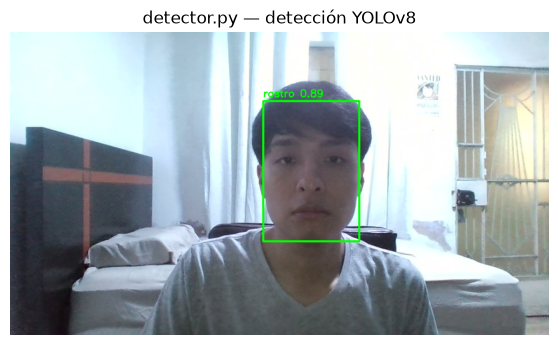

In [3]:
from src.detector import FaceDetector

detector = FaceDetector(str(MODELO_YOLO), conf_threshold=0.5)
print(f"Modelo YOLO cargado. Umbral de confianza = {detector.conf_threshold}")

# Foto de prueba (un rostro conocido del dataset)
foto = DATASET / "Gerardo_Leon_Chacon" / "gerardo_frontal_01.jpg"
frame = cv2.imread(str(foto))
print(f"Imagen: {foto.name}  →  {frame.shape[1]}x{frame.shape[0]} px")

detecciones = detector.detect(frame)
print(f"\nRostros detectados: {len(detecciones)}")
for x1, y1, x2, y2, conf, tid in detecciones:
    print(f"  caja=({x1},{y1},{x2},{y2})  confianza={conf:.3f}  track_id={tid}")

# Dibujar las cajas
vis = frame.copy()
for x1, y1, x2, y2, conf, tid in detecciones:
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(vis, f"rostro {conf:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
mostrar(vis, "detector.py — detección YOLOv8")

El método **`crop_face`** recorta el rostro (con margen) para pasárselo luego al
reconocedor. Así se ve el recorte que alimentará a `face_recognition`:

Recorte del rostro: 364x531 px (BGR)


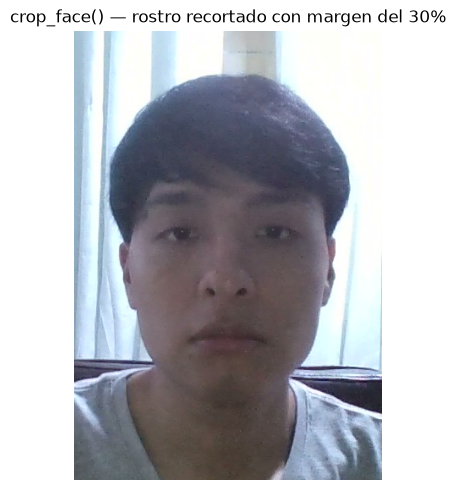

In [4]:
recorte = detector.crop_face(frame, detecciones[0])
print(f"Recorte del rostro: {recorte.shape[1]}x{recorte.shape[0]} px (BGR)")
mostrar(recorte, "crop_face() — rostro recortado con margen del 30%", ancho=4)

---
## 3. `embedding_db.py` — generación de la base de embeddings

Un **embedding** es un vector de **128 números** que representa un rostro. Lo produce
la CNN `dlib_face_recognition_resnet_model_v1` (entrenada con *triplet loss* sobre LFW):
rostros de la **misma** persona → vectores **cercanos**; personas **distintas** →
vectores **lejanos**.

La clase **`EmbeddingDB`** recorre `dataset/known_faces/` (una subcarpeta por persona),
detecta el rostro de cada foto con YOLO, genera su embedding y guarda el diccionario
`{nombre: [vector_128d, ...]}` en `embeddings.pkl`.

> Esta celda **regenera** `embeddings.pkl` desde las fotos reales (puede tardar unos
> segundos). Verás el log por persona y un resumen final.

In [5]:
from src.embedding_db import EmbeddingDB

db = EmbeddingDB(ruta_dataset=DATASET)
embeddings = db.generar()   # imprime progreso por persona + resumen
db.guardar(EMBEDDINGS)      # escribe embeddings.pkl y fallidos.txt

  Gerardo_Leon_Chacon: 15 fotos, 0 fallidas, 15 embeddings
  Kevin_Bohorquez_Huaringa: 21 fotos, 0 fallidas, 21 embeddings
WARNING GMC failed, falling back to identity: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1415: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'

WARNING GMC failed, falling back to identity: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1415: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'

WARNING GMC failed, falling back to identity: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1415: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in functio

Inspeccionamos la base generada: cuántos embeddings hay por persona y cómo luce un
vector de 128 dimensiones.

Personas en la base: ['Gerardo_Leon_Chacon', 'Kevin_Bohorquez_Huaringa', 'Miguel_Taco_Zavala']

  Gerardo_Leon_Chacon          → 15 embeddings de dim 128
  Kevin_Bohorquez_Huaringa     → 21 embeddings de dim 128
  Miguel_Taco_Zavala           → 14 embeddings de dim 128

Ejemplo — primeros 8 valores de un embedding de 128 dimensiones:
[    -0.1392      0.1456      0.0318     -0.0235     -0.0997      0.0132      0.0319     -0.0706]


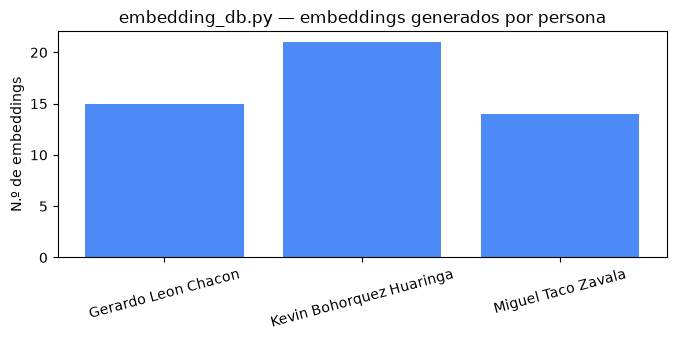

In [6]:
print("Personas en la base:", list(embeddings.keys()))
print()
for nombre, vectores in embeddings.items():
    print(f"  {nombre:28s} → {len(vectores)} embeddings de dim {len(vectores[0])}")

primer_vector = next(iter(embeddings.values()))[0]
print("\nEjemplo — primeros 8 valores de un embedding de 128 dimensiones:")
print(np.round(primer_vector[:8], 4))

# Gráfico: cantidad de embeddings por persona
plt.figure(figsize=(7, 3.5))
nombres = [n.replace("_", " ") for n in embeddings.keys()]
cantidades = [len(v) for v in embeddings.values()]
plt.bar(nombres, cantidades, color="#4C8BF5")
plt.ylabel("N.º de embeddings")
plt.title("embedding_db.py — embeddings generados por persona")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
## 4. `recognizer.py` — reconocimiento por distancia euclidiana

La clase **`FaceRecognizer`** responde a **¿*quién* es este rostro?**. Carga
`embeddings.pkl` y, para cada persona, calcula su **centroide** (el promedio de todos
sus embeddings) — más robusto que comparar foto a foto.

**`recognize(rostro_bgr)`**:
1. Extrae el embedding del recorte con `face_recognition`.
2. Calcula la distancia euclidiana al centroide de cada persona.
3. Si la menor distancia `< threshold` → devuelve `(nombre, distancia)`; si no → `("Desconocido", distancia)`.

Usamos el **umbral calibrado 0.40** (Exp. 4), no el 0.6 por defecto de la librería.

In [7]:
from src.recognizer import FaceRecognizer
from src import configuracion as cfg

recognizer = FaceRecognizer(str(EMBEDDINGS), threshold=cfg.RECOGNITION_THRESHOLD)
print(f"Umbral de reconocimiento = {recognizer.threshold}")
print(f"Centroides calculados para: {list(recognizer._centroids.keys())}")

Base de embeddings cargada: 3 persona(s)
Umbral de reconocimiento = 0.4
Centroides calculados para: ['Gerardo_Leon_Chacon', 'Kevin_Bohorquez_Huaringa', 'Miguel_Taco_Zavala']


### 4.1 Reconocer a una persona conocida
Detectamos el rostro con YOLO, lo recortamos y lo pasamos al reconocedor.

Resultado: Kevin_Bohorquez_Huaringa  (distancia = 0.194, umbral = 0.4)


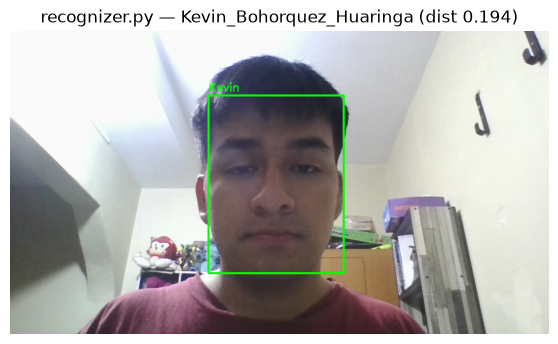

In [8]:
foto_conocida = DATASET / "Kevin_Bohorquez_Huaringa" / "foto1.jpg"
frame_k = cv2.imread(str(foto_conocida))
dets_k = detector.detect(frame_k)
crop_k = detector.crop_face(frame_k, dets_k[0])

nombre, distancia = recognizer.recognize(crop_k)
print(f"Resultado: {nombre}  (distancia = {distancia:.3f}, umbral = {recognizer.threshold})")

vis = frame_k.copy()
x1, y1, x2, y2, *_ = dets_k[0]
color = (0, 0, 255) if nombre == "Desconocido" else (0, 255, 0)
cv2.rectangle(vis, (x1, y1), (x2, y2), color, 3)
cv2.putText(vis, nombre.split("_")[0], (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
mostrar(vis, f"recognizer.py — {nombre} (dist {distancia:.3f})")

### 4.2 Reconocer a un desconocido
Con una persona que **no** está en la base, la distancia mínima supera el umbral y el
sistema responde `"Desconocido"`.

WARNING GMC failed, falling back to identity: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1415: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'

Resultado: Desconocido  (distancia = 0.722, umbral = 0.4)


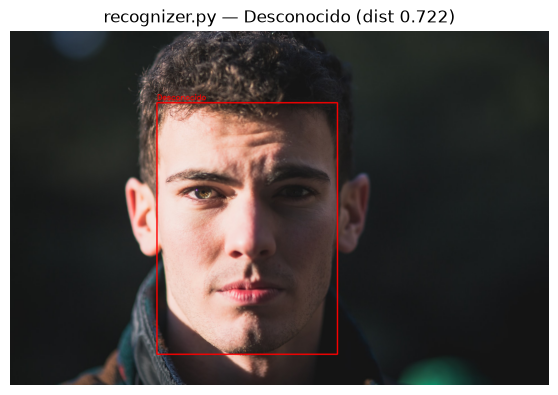

In [10]:
foto_desconocida = RAIZ / "dataset" / "unknown_faces" / "persona1.jpg"
frame_d = cv2.imread(str(foto_desconocida))
dets_d = detector.detect(frame_d)

if dets_d:
    crop_d = detector.crop_face(frame_d, dets_d[0])
    nombre_d, dist_d = recognizer.recognize(crop_d)
    print(f"Resultado: {nombre_d}  (distancia = {dist_d:.3f}, umbral = {recognizer.threshold})")

    vis = frame_d.copy()
    x1, y1, x2, y2, *_ = dets_d[0]
    color = (0, 0, 255) if nombre_d == "Desconocido" else (0, 255, 0)
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 3)
    cv2.putText(vis, nombre_d, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    mostrar(vis, f"recognizer.py — {nombre_d} (dist {dist_d:.3f})")
else:
    print("No se detectó rostro en la imagen de prueba.")

### 4.3 ¿Por qué funciona? Distancias a cada centroide
Mostramos la distancia del rostro conocido a **cada** persona registrada: la propia
persona queda muy por debajo del umbral y las demás muy por encima. Ese "margen" es lo
que permite decidir con seguridad.

In [11]:
import face_recognition

rgb = cv2.cvtColor(crop_k, cv2.COLOR_BGR2RGB)
emb = face_recognition.face_encodings(rgb)[0]

print(f"Rostro de prueba: {foto_conocida.parent.name}\n")
print(f"{'Persona':28s} {'distancia':>10s}   ¿< umbral?")
print("-" * 55)
for persona, centroide in recognizer._centroids.items():
    d = float(np.linalg.norm(emb - centroide))
    marca = "  <-- coincide" if d < recognizer.threshold else ""
    print(f"{persona:28s} {d:10.3f}   {'sí' if d < recognizer.threshold else 'no'}{marca}")

Rostro de prueba: Kevin_Bohorquez_Huaringa

Persona                       distancia   ¿< umbral?
-------------------------------------------------------
Gerardo_Leon_Chacon               0.474   no
Kevin_Bohorquez_Huaringa          0.194   sí  <-- coincide
Miguel_Taco_Zavala                0.594   no


---
## 5. `tracker.py` — periodo de gracia por `track_id`

Reconocer en **cada** frame sería costoso e inestable. La clase **`Tracker`** aplica un
**periodo de gracia**: cuando aparece un `track_id` nuevo, durante los primeros
`grace_frames` solo se muestra *"Reconociendo..."*. Al expirar, se reconoce **una sola
vez** y el nombre queda **cacheado** para ese `track_id`.

- `is_grace(id)` → `True` mientras siga en gracia (va descontando frames).
- `get_name(id)` → nombre confirmado o `None`.
- `confirm(id, nombre)` → cachea el nombre.

Simulamos la vida de un `track_id` sin necesidad de cámara:

In [12]:
from src.tracker import Tracker

tracker = Tracker(grace_frames=5)   # 5 para que la demo sea corta
track_id = 42

print(f"{'frame':>5s}  {'get_name':<14s} {'is_grace':<9s}  acción")
print("-" * 55)
for f in range(1, 9):
    nombre = tracker.get_name(track_id)
    if nombre is None:
        en_gracia = tracker.is_grace(track_id)
        if en_gracia:
            accion = 'mostrar "Reconociendo..."'
        else:
            # gracia expiró: se reconoce una vez y se cachea
            tracker.confirm(track_id, "Gerardo_Leon_Chacon")
            accion = "→ recognize() UNA vez  →  confirm('Gerardo')"
        print(f"{f:5d}  {str(nombre):<14s} {str(en_gracia):<9s}  {accion}")
    else:
        print(f"{f:5d}  {nombre.split('_')[0]:<14s} {'—':<9s}  usa nombre cacheado (sin recalcular)")

frame  get_name       is_grace   acción
-------------------------------------------------------
    1  None           True       mostrar "Reconociendo..."
    2  None           True       mostrar "Reconociendo..."
    3  None           True       mostrar "Reconociendo..."
    4  None           True       mostrar "Reconociendo..."
    5  None           False      → recognize() UNA vez  →  confirm('Gerardo')
    6  Gerardo        —          usa nombre cacheado (sin recalcular)
    7  Gerardo        —          usa nombre cacheado (sin recalcular)
    8  Gerardo        —          usa nombre cacheado (sin recalcular)


---
## 6. `asistencia.py` — registro de asistencia en CSV

La clase **`AsistenciaDB`** crea/abre un archivo `data/asistencia_AAAA-MM-DD.csv` y
registra a cada persona reconocida **una sola vez por día** (columnas `id`,
`trabajador`, `hora`). Si se intenta registrar de nuevo a alguien ya presente, lo
ignora — así no se duplica el acceso frame a frame.

In [13]:
from src.asistencia import AsistenciaDB
import pandas as pd

asistencia = AsistenciaDB()
print("Archivo del día:", asistencia.ruta.relative_to(RAIZ))

# Registrar algunas personas (la repetida se ignora)
asistencia.registrar("Gerardo Leon Chacon")
asistencia.registrar("Kevin Bohorquez Huaringa")
asistencia.registrar("Gerardo Leon Chacon")   # duplicado → ignorado
asistencia.registrar("Miguel Taco Zavala")

df = pd.read_csv(asistencia.ruta)
print(f"\nFilas en el CSV: {len(df)} (Gerardo aparece una sola vez)")
df

Archivo del día: data\asistencia_2026-07-08.csv

Filas en el CSV: 3 (Gerardo aparece una sola vez)


,id,trabajador,hora
0,1,Gerardo Leon Chacon,18:11:12
1,2,Kevin Bohorquez Huaringa,18:11:12
2,3,Miguel Taco Zavala,18:11:12


---
## 7. `interfaz.py` — dashboard "Control de acceso — en vivo"

En vez de una ventana de video pelada, `interfaz.py` compone un **panel completo** sobre
un lienzo de OpenCV: cabecera con reloj y FPS, panel de cámara con cajas de colores
(verde = reconocido, rojo = desconocido, naranja = procesando), lista de *"Últimos
accesos"*, tarjetas de estadísticas y panel de controles. El texto se dibuja con
PIL/Pillow para tener acentos y tipografía limpia.

Aquí generamos **un frame del dashboard** a partir de una imagen estática (sin cámara),
para mostrar cómo se ve en la exposición.

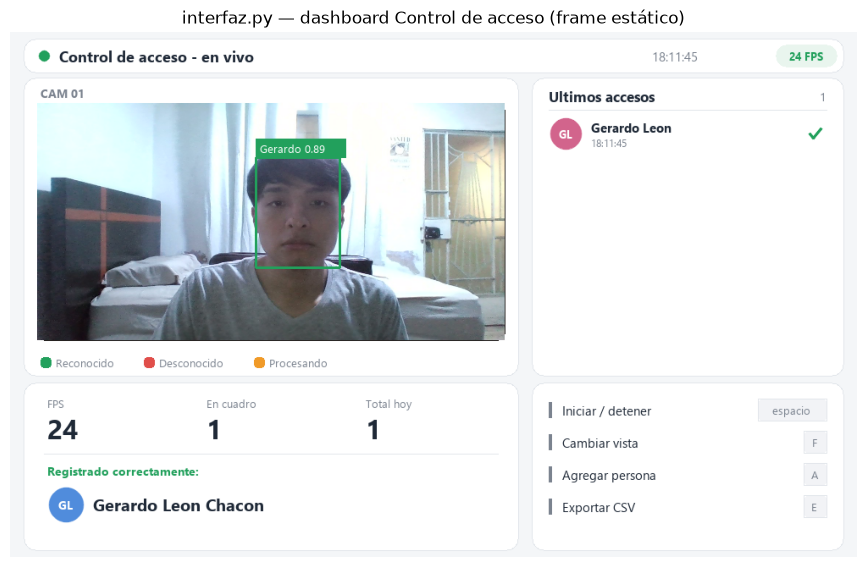

In [14]:
from src import interfaz

# Preparamos un "frame" con detecciones y nombres ya confirmados
frame_ui = cv2.imread(str(DATASET / "Gerardo_Leon_Chacon" / "gerardo_frontal_01.jpg"))
dets_ui = detector.detect(frame_ui)

tracker_ui = Tracker(grace_frames=1)
dash = interfaz.Dashboard()
dash.fps = 24.0
for det in dets_ui:
    tid = det[5]
    crop = detector.crop_face(frame_ui, det)
    nombre, _ = recognizer.recognize(crop)
    tracker_ui.confirm(tid, nombre)
    dash.registrar_acceso(nombre)
dash.en_cuadro = len(dets_ui)

# Componer el dashboard completo
lienzo = interfaz.componer_dashboard(frame_ui, dets_ui, tracker_ui, dash, corriendo=True)
mostrar(lienzo, "interfaz.py — dashboard Control de acceso (frame estático)", ancho=11)

---
## 8. `main.py` — orquestación del bucle en tiempo real

`main.py` es el **director de orquesta**: abre la cámara y, por cada frame, encadena
todos los módulos anteriores:

```python
detections = detector.detect(frame)                 # detector.py
for det in detections:
    name = tracker.get_name(track_id)                # tracker.py
    if name is None and not tracker.is_grace(...):   # periodo de gracia
        crop = detector.crop_face(frame, det)        # detector.py
        name, dist = recognizer.recognize(crop)      # recognizer.py
        tracker.confirm(track_id, name)
        if name != "Desconocido":
            asistencia.registrar(name)               # asistencia.py
    # dibuja caja verde/naranja/rojo + nombre        # OpenCV
```

Como en el notebook no hay cámara, **replicamos ese mismo bucle sobre un video de
prueba**: procesamos varios frames (para que expire el periodo de gracia) y mostramos
un frame anotado con el resultado del pipeline completo.

Base de embeddings cargada: 3 persona(s)
Procesados 40 frames del video de prueba.
Identidades confirmadas por track_id: {1: 'Desconocido'}


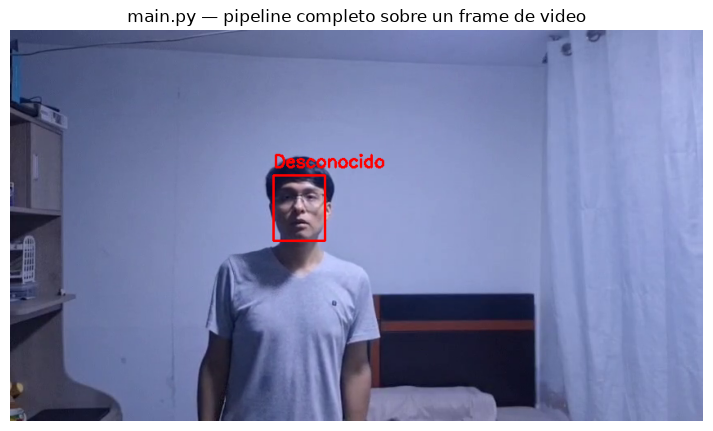

In [17]:
from src.tracker import Tracker

video = RAIZ / "dataset" / "test_videos" / "video_corto_prueba.mp4"
cap = cv2.VideoCapture(str(video))

detector_rt  = FaceDetector(str(MODELO_YOLO), conf_threshold=cfg.DETECTION_CONFIDENCE)
recog_rt     = FaceRecognizer(str(EMBEDDINGS), threshold=cfg.RECOGNITION_THRESHOLD)
tracker_rt   = Tracker(grace_frames=10)
COLORES = {"Reconociendo...": (0, 165, 255), "Desconocido": (0, 0, 255)}

frame_anotado = None
N_FRAMES = 40   # suficientes para que el tracker confirme identidades

for i in range(N_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break

    detections = detector_rt.detect(frame)
    for det in detections:
        x1, y1, x2, y2, _, tid = det
        name = tracker_rt.get_name(tid)
        if name is None:
            if not tracker_rt.is_grace(tid):
                crop = detector_rt.crop_face(frame, det)
                if crop is not None:
                    name, dist = recog_rt.recognize(crop)
                    tracker_rt.confirm(tid, name)
            etiqueta = name or "Reconociendo..."
            etiqueta = etiqueta.split("_")[0] if etiqueta not in COLORES else etiqueta
        else:
            etiqueta = name.split("_")[0]

        color = COLORES.get(etiqueta, (0, 255, 0))
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, etiqueta, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    frame_anotado = frame

cap.release()

if frame_anotado is not None:
    print(f"Procesados {N_FRAMES} frames del video de prueba.")
    print("Identidades confirmadas por track_id:", tracker_rt._confirmed)
    mostrar(frame_anotado, "main.py — pipeline completo sobre un frame de video", ancho=9)
else:
    print("No se pudo leer el video de prueba.")

---
## 9. Resultados de los experimentos (justifican los parámetros)

Cada parámetro del sistema se **calibró experimentalmente**. Aquí resumimos los
gráficos clave (guardados en `experiments/graphs/`).

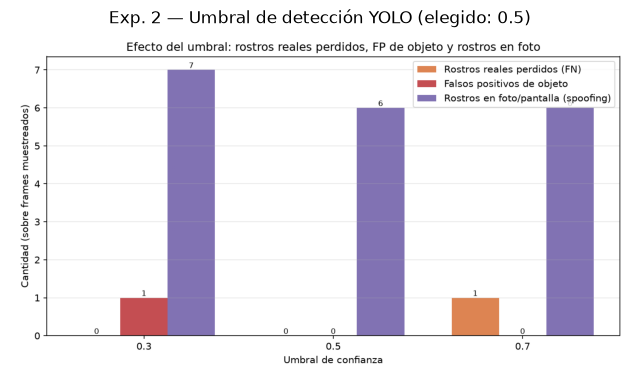

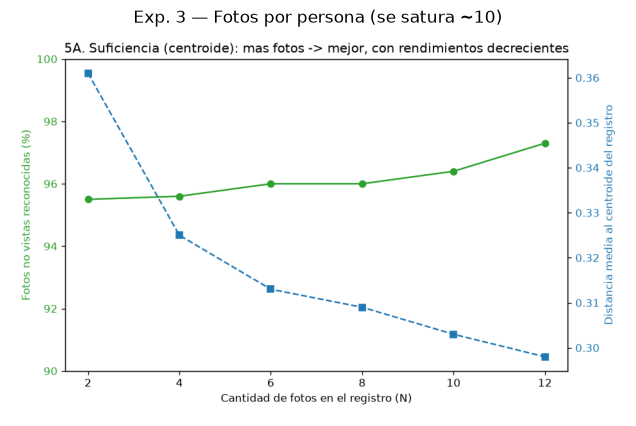

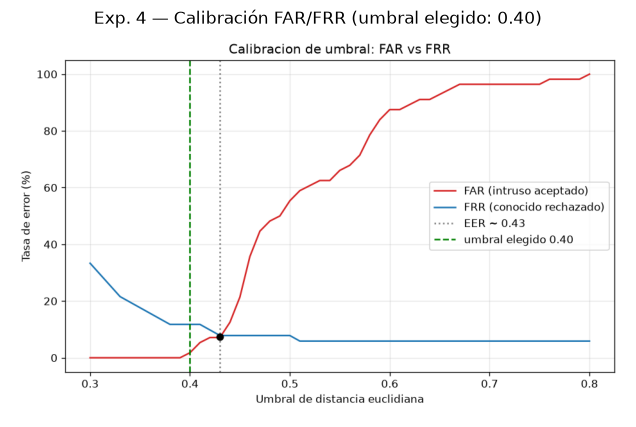

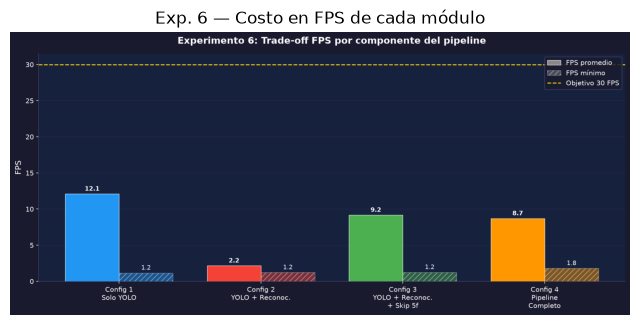

In [18]:
graphs = RAIZ / "experiments" / "graphs"
figuras = [
    ("exp2_comparacion_umbrales.png", "Exp. 2 — Umbral de detección YOLO (elegido: 0.5)"),
    ("exp3_suficiencia.png",          "Exp. 3 — Fotos por persona (se satura ~10)"),
    ("calibracion_umbral.png",        "Exp. 4 — Calibración FAR/FRR (umbral elegido: 0.40)"),
    ("exp6_fps_barras.png",           "Exp. 6 — Costo en FPS de cada módulo"),
]

for archivo, titulo in figuras:
    ruta = graphs / archivo
    if ruta.exists():
        img = plt.imread(str(ruta))
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.title(titulo)
        plt.axis("off")
        plt.show()
    else:
        print(f"[falta] {ruta.relative_to(RAIZ)}")

| Experimento | Parámetro justificado | Resultado |
|---|---|---|
| **Exp. 1** — rendimiento base | — | Detector ~24–27 FPS, confianza ~0.86 → sobra margen para tiempo real. |
| **Exp. 2** — umbral de detección | `DETECTION_CONFIDENCE = 0.5` | Único umbral con **0 errores** (0.3 da falso positivo, 0.7 pierde un rostro). |
| **Exp. 3** — fotos por persona | `FOTOS_POR_PERSONA ≈ 10` | El acierto se **satura ~10 fotos**; 100 % de embeddings generados (51/51). |
| **Exp. 4** — umbral de reconocimiento | `RECOGNITION_THRESHOLD = 0.40` | Baja el **FAR del 87.5 % al 1.8 %** (control de acceso → priorizar FAR bajo). |
| **Exp. 6** — trade-off de rendimiento | `RECOGNIZE_EVERY_N_FRAMES` | Cuantifica el costo en FPS de cada componente. |

---
## 10. Conclusiones

1. El sistema integra en una sola tubería **detección (YOLOv8)**, **seguimiento
   (ByteTrack)** y **reconocimiento por embeddings (dlib/ResNet)**, y **opera en tiempo
   real** (~24 FPS) sobre hardware sin GPU dedicada.
2. La arquitectura está **modularizada** con responsabilidades separadas
   (`detector`, `recognizer`, `tracker`, `asistencia`, `interfaz`, `main`), lo que
   facilita probar y explicar cada pieza por separado — como en este notebook.
3. **Cada parámetro está justificado experimentalmente**: umbral de detección (0.5),
   fotos de registro (~10) y umbral de reconocimiento (0.40).
4. La calibración con curvas **FAR/FRR** fue determinante: el valor por defecto de la
   librería (0.60) era inseguro para esta base (**FAR 87.5 %**); con **0.40** el FAR
   baja al **1.8 %**, apropiado para control de acceso.

**Trabajo futuro:** *anti-spoofing* (detección de vida), evaluación con un padrón mayor
y aceleración por GPU.